In [2]:
import pandas as pd
import numpy as np

# 数据列表，每行对应表格的一行
data_bbqg = [
    ["Qwen2.5-7B-Instruct", "minimal+reranker", 74, 115, 55, 88, 134, 461.22, 291, 161, 144],
    ["Qwen2.5-7B-Instruct", "minimal+rewriter+reranker", 92, 143, 72, 111, 198, 779.15, 485, 214, 196],
    ["Qwen2.5-7B-Instruct", "minimal+reranker+summarizer", 20, 103, 19, 87, 110, 199.06, 150, 167, 162],
    ["Qwen2.5-14B-Instruct", "minimal+reranker", 50, 101, 39, 87, 126, 178.39, 141, 159, 140],
    ["Qwen2.5-14B-Instruct", "minimal+rewriter+reranker", 71, 147, 56, 120, 183, 210.08, 200, 206, 182],
    ["Qwen2.5-14B-Instruct", "minimal+reranker+summarizer", 15, 77, 11, 61, 103, 101.66, 98, 139, 134],
    ["Qwen2.5-32B-Instruct", "minimal+reranker", 79, 149, 65, 129, 130, 155, 136, 184, 163],
    ["Qwen2.5-32B-Instruct", "minimal+rewriter+reranker", 71, 135, 53, 112, 164, 154.52, 141, 189, 155],
    ["Qwen2.5-32B-Instruct", "minimal+reranker+summarizer", 16, 107, 13, 84, 89, 106.7, 83, 145, 130],

    # Qwen3 系列空白行，使用 NaN
    ["Qwen3-8B", "minimal+reranker", np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan],
    ["Qwen3-8B", "minimal+rewriter+reranker", np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan],
    ["Qwen3-8B", "minimal+reranker+summarizer", np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan],
    ["Qwen3-14B", "minimal+reranker", np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan],
    ["Qwen3-14B", "minimal+rewriter+reranker", np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan],
    ["Qwen3-14B", "minimal+reranker+summarizer", np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan],
    ["Qwen3-32B", "minimal+reranker", np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan],
    ["Qwen3-32B", "minimal+rewriter+reranker", np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan],
    ["Qwen3-32B", "minimal+reranker+summarizer", np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan],
]

# 创建 DataFrame
columns = [
    "LLM", "RAG",
    "rougeL_prompt05", "rougeL_prompt08", "rougeL_chunk05", "rougeL_chunk08",
    "context_prompt", "avg_words_length", "context_chunk", "embed_prompt", "embed_chunk",
]

df_bbqg = pd.DataFrame(data_bbqg, columns=columns)


import pandas as pd
import numpy as np

# 假设 df 已经存在
# 示例拆分
df_bbqg["reranker"] = df_bbqg["RAG"].str.contains("reranker", case=False, na=False)
df_bbqg["rewriter"] = df_bbqg["RAG"].str.contains("rewriter", case=False, na=False)
df_bbqg["summarizer"] = df_bbqg["RAG"].str.contains("summarizer", case=False, na=False)

# 可选：把原 RAG 列删除
# df_bbqg = df_bbqg.drop(columns=["RAG"])

# 查看结果
df_bbqg.head()

,LLM,RAG,rougeL_prompt05,rougeL_prompt08,rougeL_chunk05,rougeL_chunk08,context_prompt,avg_words_length,context_chunk,embed_prompt,embed_chunk,reranker,rewriter,summarizer
0,Qwen2.5-7B-Instruct,minimal+reranker,74.0,115.0,55.0,88.0,134.0,461.22,291.0,161.0,144.0,True,False,False
1,Qwen2.5-7B-Instruct,minimal+rewriter+reranker,92.0,143.0,72.0,111.0,198.0,779.15,485.0,214.0,196.0,True,True,False
2,Qwen2.5-7B-Instruct,minimal+reranker+summarizer,20.0,103.0,19.0,87.0,110.0,199.06,150.0,167.0,162.0,True,False,True
3,Qwen2.5-14B-Instruct,minimal+reranker,50.0,101.0,39.0,87.0,126.0,178.39,141.0,159.0,140.0,True,False,False
4,Qwen2.5-14B-Instruct,minimal+rewriter+reranker,71.0,147.0,56.0,120.0,183.0,210.08,200.0,206.0,182.0,True,True,False


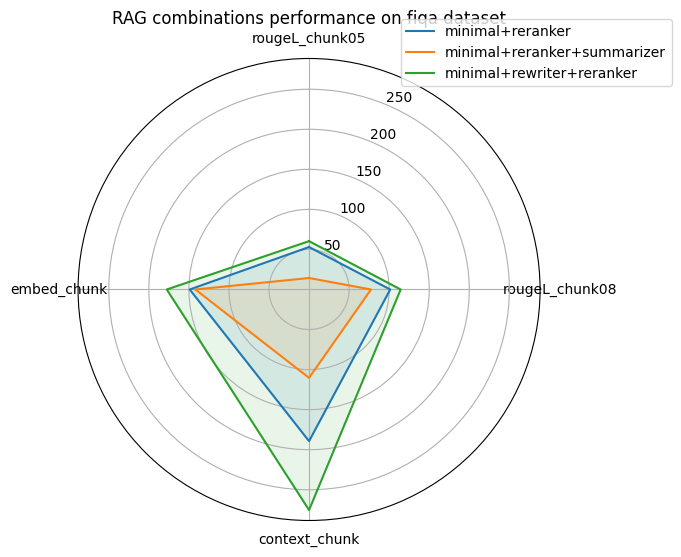

In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 选择你想展示的指标
metrics = ["rougeL_chunk05", "rougeL_chunk08", "context_chunk", "embed_chunk"]

# 按 RAG 分组取均值（可以按 LLM 进一步筛选，如果只看某个模型）
df_plot = df_bbqg.groupby("RAG")[metrics].mean()

# 准备雷达图
labels = metrics
num_vars = len(labels)

angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]  # 闭合多边形

fig, ax = plt.subplots(figsize=(6,6), subplot_kw=dict(polar=True))

# 绘制每个 RAG
for rag in df_plot.index:
    values = df_plot.loc[rag].tolist()
    values += values[:1]  # 闭合
    ax.plot(angles, values, label=rag)
    ax.fill(angles, values, alpha=0.1)

# 设置雷达图
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_thetagrids(np.degrees(angles[:-1]), labels)
ax.set_title("RAG combinations performance on fiqa dataset")
ax.grid(True)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))

plt.show()

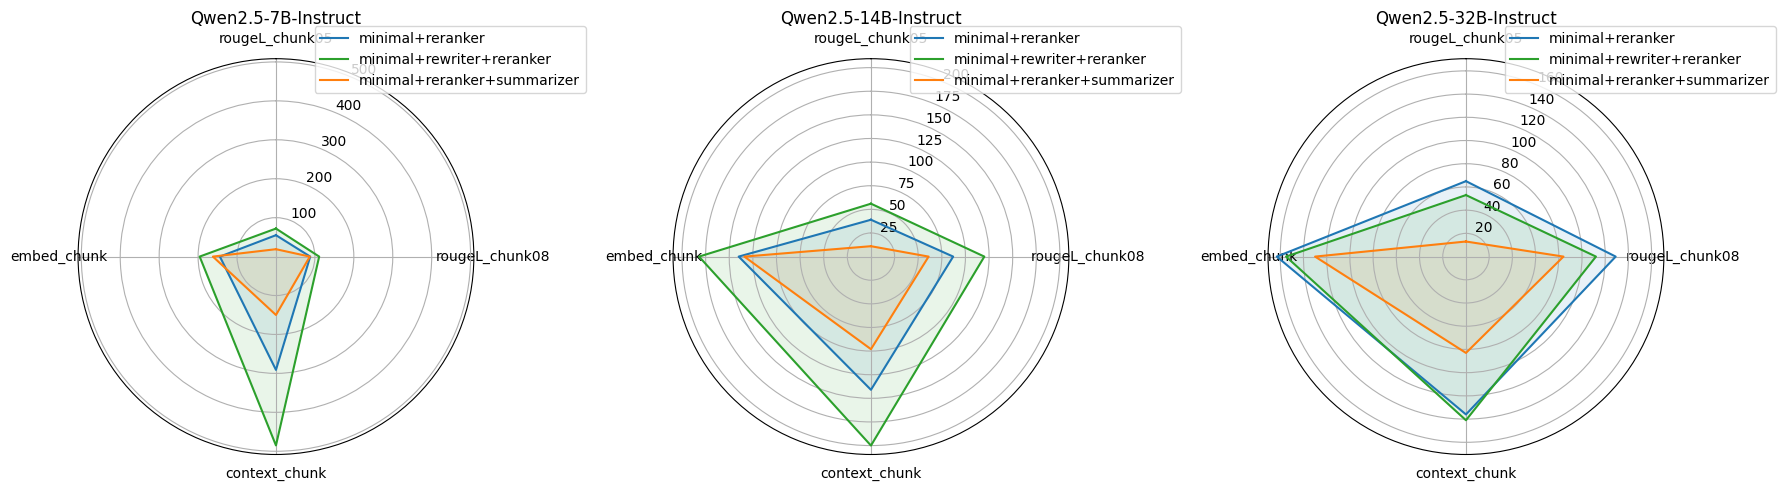

In [8]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# 你想要的 RAG 顺序
desired_order = ["minimal+reranker", "minimal+rewriter+reranker", "minimal+reranker+summarizer"]

# 指标
metrics = ["rougeL_chunk05", "rougeL_chunk08", "context_chunk", "embed_chunk"]

# 只保留有数据的 LLM
llms_with_data = []
for llm in df_bbqg["LLM"].unique():
    df_l = df_bbqg[df_bbqg["LLM"] == llm]
    if df_l[metrics].notna().any().any():
        llms_with_data.append(llm)

n_llm = len(llms_with_data)
fig, axes = plt.subplots(1, n_llm, figsize=(6*n_llm, 6), subplot_kw=dict(polar=True))
if n_llm == 1:
    axes = [axes]

for ax, llm in zip(axes, llms_with_data):
    df_l = df_bbqg[df_bbqg["LLM"] == llm]
    df_plot = df_l.groupby("RAG")[metrics].mean()
    
    # 跳过整行全 NaN 的 RAG
    df_plot = df_plot.dropna(how="all")
    if df_plot.empty:
        ax.set_title(f"{llm} (no data)")
        continue
    
    # 归一化
    # scaler = MinMaxScaler()
    # df_scaled = pd.DataFrame(scaler.fit_transform(df_plot), index=df_plot.index, columns=metrics)
    df_scaled = df_plot.copy()
    
    # 雷达图角度
    angles = np.linspace(0, 2*np.pi, len(metrics), endpoint=False).tolist()
    angles += angles[:1]
    
    # 绘制每个 RAG
    for rag in df_scaled.index:
        values = df_scaled.loc[rag].tolist()
        values += values[:1]  # 闭合
        # ax.plot(angles, values, label=rag, marker='o')  # 加 marker
        ax.plot(angles, values, label=rag)  # 加 marker
        ax.fill(angles, values, alpha=0.1)
    
    # 设置雷达图样式
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_thetagrids(np.degrees(angles[:-1]), metrics)
    ax.set_title(f"{llm}")
    ax.grid(True)
    
    # legend 按指定顺序
    handles, labels = ax.get_legend_handles_labels()
    order = [labels.index(rag) for rag in desired_order if rag in labels]
    handles = [handles[i] for i in order]
    labels = [labels[i] for i in order]
    ax.legend(handles, labels, loc="upper right", bbox_to_anchor=(1.3, 1.1))

plt.tight_layout()
plt.show()
